# Osyczka and Kundu function multi-objective optimization (min).
---
Description:

- Optimization (min)
- Multi-objective (2)
- Constraints (6)
---

Minimize the equations given by:

\begin{cases}
      f_{1}\left(\mathbf{x}\right) = -25(x_1 - 2)^2 - (x_2 - 2)^2 - (x_3 - 1)^2 - (x_4 - 4)^2 - (x_5 - 1)^2, \\
      f_{2}\left(\mathbf{x}\right) = x_1^2 + x_2^2 + x_3^2 + x_4^2 + x_5^2 + x_6^2, \\
\end{cases}

subject to:

\begin{cases}
      g_{1}\left(\mathbf{x}\right) = (x_1 + x_2 − 2) \geq 0, \\
      g_{2}\left(\mathbf{x}\right) = (6 - x_1 − x_2) \geq 0, \\
      g_{3}\left(\mathbf{x}\right) = (2 - x_2 + x_1) \geq 0, \\
      g_{4}\left(\mathbf{x}\right) = (2 − x_1 + 3x_2) \geq 0, \\
      g_{5}\left(\mathbf{x}\right) = (4 − (x_3 − 3)^2 − x_4) \geq 0, \\
      g_{6}\left(\mathbf{x}\right) = ((x_5 − 3)^2 + x_6−4) \geq 0, \\
\end{cases}

where:

\begin{cases}
      0\le x_1, x_2, x_6 \le 10, \\
      1\le x_3, x_5 \le 5, \\
      0\le x_4 \le 6. \\
\end{cases}

The Pareto-optimal region is a concatenation of five regions. Every region lies on some of the constraints. However, for the entire Pareto-optimal region, $\hat{x}_4=\hat{x}_6=0$.

### First we import python libraries and set up the directory of our code.

In [1]:
import os, sys

import numpy as np

from matplotlib import pyplot as plt

PROJECT_DIR = os.path.abspath('..')

if PROJECT_DIR not in sys.path:
    sys.path.append(PROJECT_DIR)

### Here we import all our custom GA code.

In [2]:
# Import main classes.
from pygenalgo.genome.gene import Gene
from pygenalgo.genome.chromosome import Chromosome
from pygenalgo.engines.multi_objective_ga import MultiObjectiveGA
from pygenalgo.utils.utilities import cost_function, np_pareto_front

# Import Crossover Operator(s).
from pygenalgo.operators.crossover.blend_crossover import BlendCrossover

# Import Mutation Operator(s).
from pygenalgo.operators.mutation.random_mutator import RandomMutator

# Import Selection Operator(s).
from pygenalgo.operators.selection.pareto_front_selector import ParetoFrontSelector

### Define the multi-objective function, which plays also the role of the 'fitness' function.

In addition, we define a 'boundary_x', for each variable, which takes the role of the 'random()' method
of the Genes, using the required range.

In [16]:
# Multi-objective function.
@cost_function(minimize=True)
def fun_osy(individual: Chromosome):
    
    # Extract the gene values.
    x1, x2, x3, x4, x5, x6 = individual.values()

    # Compute objective function 1.
    f1: float = -(25.0*(x1 - 2.0)**2 +
                       (x2 - 2.0)**2 +
                       (x3 - 1.0)**2 +
                       (x4 - 4.0)**2 +
                       (x5 - 1.0)**2)

    # Compute objective function 2.
    f2: float = x1**2 + x2**2 + x3**2 +\
                x4**2 + x5**2 + x6**2
    
    # Compute the constraint functions.
    g1: float = min(0.0, (x1 + x2 - 2.0))**2             # >= 0.0
    g2: float = min(0.0, (6.0 - x1 - x2))**2             # >= 0.0
    g3: float = min(0.0, (2.0 - x2 + x1))**2             # >= 0.0
    g4: float = min(0.0, (2.0 - x1 + 3.0*x2))**2         # >= 0.0
    g5: float = min(0.0, (4.0 - (x3 - 3.0)**2 - x4))**2  # >= 0.0
    g6: float = min(0.0, (x5 - 3.0)**2 + x6 - 4.0)**2    # >= 0.0

    # Add up penalty terms.
    penalty: float = g1 + g2 + g3 + g4 + g5 + g6

    return (f1, f2, penalty), False
# _end_def_

Here we set the GA parameters, such as number of genes, number of chromosomes, etc. Note that in this case each gene has different random() function, because they are valid in different ranges according to the 
problem definition.

In [17]:
# Random number generator.
rng = np.random.default_rng()

# Random boundary functions (one for each variable):
boundary_x1 = lambda: rng.uniform(0.0, 10.0)
boundary_x2 = lambda: rng.uniform(0.0, 10.0)
boundary_x3 = lambda: rng.uniform(1.0,  5.0)
boundary_x4 = lambda: rng.uniform(0.0,  6.0)
boundary_x5 = lambda: rng.uniform(1.0,  5.0)
boundary_x6 = lambda: rng.uniform(0.0, 10.0)

# Define the number of chromosomes.
n_pop = 400

# Initial population.
population = [Chromosome([Gene(boundary_x1(), boundary_x1),
                          Gene(boundary_x2(), boundary_x2),
                          Gene(boundary_x3(), boundary_x3),
                          Gene(boundary_x4(), boundary_x4),
                          Gene(boundary_x5(), boundary_x5),
                          Gene(boundary_x6(), boundary_x6)], None, True)
              for _ in range(n_pop)]

# Create the MultiObjectiveGA object that will carry on the optimization.
test_GA = MultiObjectiveGA(initial_pop=population,
                           fit_func=fun_osy,
                           select_op=ParetoFrontSelector(n_contestants=20),
                           mutate_op=RandomMutator(),
                           crossx_op=BlendCrossover(lower_lim=[ 0.0,  0.0, 1.0, 0.0, 1.0,  0.0],
                                                    upper_lim=[10.0, 10.0, 5.0, 6.0, 5.0, 10.0]))

### Optimization process.

Here we call the GA object (either directly, or through the method run()). We set a number of parameter, such as the maximum iterations (i.e. epochs), tolerance for the fitness convergences, etc.

In [18]:
test_GA(epochs=350, elitism=True)

07/30/2026 09:53:54 INFO: Initial Avg. Fitness = [ 486.0564 -134.8576  -40.913 ]
07/30/2026 09:54:02 INFO: Final Avg. Fitness = [735.191  -88.8599 -17.0574]


Elapsed time: 8.507 seconds.


In [19]:
def osy_function(x):
    """
    Helper function for ploting the Pareto front.
    """
    # Extract the values.
    x1, x2, x3, x4, x5, x6 = x

    # Compute the constraints.
    c1: bool = (x1 + x2 - 2.0) >= 0.0
    c2: bool = (6.0 - x1 - x2) >= 0.0
    c3: bool = (2.0 - x2 + x1) >= 0.0
    c4: bool = (2.0 - x1 + 3.0*x2) >= 0.0
    c5: bool = (4.0 - (x3 - 3.0)**2 - x4) >= 0.0
    c6: bool = (x5 - 3.0)**2 + x6 - 4.0 >= 0.0

    # Check validity for all the conditions.
    if c1 and c2 and c3 and c4 and c5 and c6:

        # Compute objective function 1.
        f1 = -(25.0*(x1 - 2.0)**2 +
                    (x2 - 2.0)**2 +
                    (x3 - 1.0)**2 +
                    (x4 - 4.0)**2 +
                    (x5 - 1.0)**2)
    
        # Compute objective function 2.
        f2 = x1**2 + x2**2 + x3**2 +\
             x4**2 + x5**2 + x6**2
        
        # Feasible point.
        return f1, f2, True
        
    # Infeasible point.
    return None, None, False
# _end_def_

In [20]:
true_pareto = []

# Define search boundaries for random uniform sampling [min, max]
bounds = np.array([
    [0.0, 10.0],  # x1
    [0.0, 10.0],  # x2
    [1.0,  5.0],  # x3
    [0.0,  6.0],  # x4
    [1.0,  5.0],  # x5
    [0.0, 10.0]   # x6
])

# Generate random guesses within explicit bounds
random_samples = np.random.uniform(bounds[:, 0],
                                   bounds[:, 1],
                                   size=(100000, 6))
for x in random_samples:

    # Get the OSY function values.
    f1, f2, is_feasible = osy_function(x)

    # Check the condition.
    if is_feasible:
        # Add them to the list.
        true_pareto.append((f1, f2))
# _end_for_

# Convert to numpy
true_pareto = np.array(true_pareto)

# Estimate the pareto front points.
true_pareto = np_pareto_front(true_pareto, "min")

In [21]:
best_n = []

for p in test_GA.population:

    # Get the OSY function values.
    f1, f2, is_feasible = osy_function(p.values())

    # Check the condition.
    if is_feasible:
        
        # Add them to the list.
        best_n.append((f1, f2))
# _end_for_

# Convert lists to numpy.
best_n = np.array(best_n)

# Estimate the pareto front points.
pareto_best_n = np_pareto_front(best_n, "min")

### Visualize the solution on the Pareto plot.

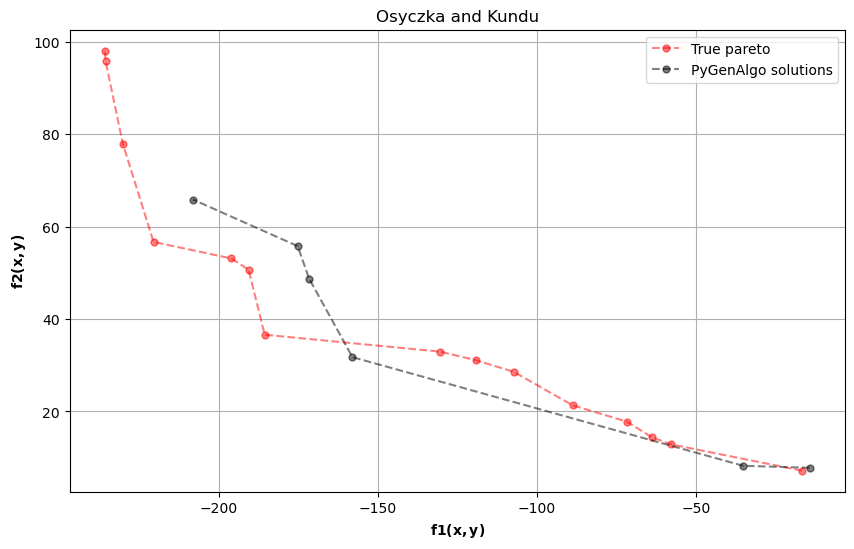

In [22]:
# Create a new figure.
plt.figure(figsize=(10, 6))

# Plot the best_n.
plt.plot(true_pareto[:, 0],
         true_pareto[:, 1], "ro--", alpha=0.5,
         markersize=5, label="True pareto")

# Plot the best_n.
plt.plot(pareto_best_n[:, 0],
         pareto_best_n[:, 1], "ko--", alpha=0.5,
         markersize=5, label="PyGenAlgo solutions")

# Tidy up the plot.
plt.title("Osyczka and Kundu")
plt.xlabel(r"$\mathbf{f1(x,y)}$")
plt.ylabel(r"$\mathbf{f2(x,y)}$")
plt.legend()
plt.grid(True)

plt.savefig("Osyczka_and_Kundu_pareto.pdf", format="pdf", dpi=300)

### End of file